In [1]:
import polars as pl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
from pathlib import Path


In [ ]:
# Load and Merge predictions parquet files
base = Path(r"C:\Users\chris\OneDrive - Danmarks Tekniske Universitet\Documents\DTU\Thesis\Green Power and KONSTANT\MSc_thesis_github_repo\MSc-Thesis")
rf_preds_path = base / "data" / "rf_predictions" /"rf_merged_predictions.parquet"
xgb_preds_path = base / "data" / "xgb_predictions" /"xgb_merged_predictions.parquet"

lf_rf = (pl.scan_parquet(rf_preds_path)
.rename({"EV_probability_mean": "rf_EV_probability", "FAMDISPONIBEL_13_mean": "Family_Income_rf"})
.select(["bucket_idx", "week_id","Family_Income_rf", "rf_EV_probability"])
)
lf_xgb = (pl.scan_parquet(xgb_preds_path)
.rename({"EV_probability_mean": "xgb_EV_probability", "FAMDISPONIBEL_13_mean": "Family_Income_xgb"})
.select(["bucket_idx", "week_id","Family_Income_xgb", "xgb_EV_probability"])
)

df_rf = lf_rf.collect(engine = "streaming")
df_xgb = lf_xgb.collect(engine = "streaming")

# pd_rf = df_rf.head(100).to_pandas()
# pd_xgb = df_xgb.head(100).to_pandas()

lf_corr = lf_rf.join(lf_xgb, on=["bucket_idx", "week_id"], how="inner")
df_corr = lf_corr.collect(engine = "streaming")
# pd_corr = df_corr.head(100).to_pandas()

In [7]:
# Correlation calculation
weekly_corr = df_corr.select([
    pl.corr("rf_EV_probability", "xgb_EV_probability", method="pearson").alias("RF-XGB Pearson_corr"),
    pl.corr("rf_EV_probability", "Family_Income_rf", method="pearson").alias("RF - Family_Income Pearson_corr"),
    pl.corr("xgb_EV_probability", "Family_Income_xgb", method="pearson").alias("XGB - Family_Income Pearson_corr"),
    pl.corr("rf_EV_probability", "xgb_EV_probability", method="spearman").alias("RF-XGB Spearman_corr"),
    pl.corr("rf_EV_probability", "Family_Income_rf", method="spearman").alias("RF - Family_Income Spearman_corr"),
    pl.corr("xgb_EV_probability", "Family_Income_xgb", method="spearman").alias("XGB - Family_Income Spearman_corr")
]
)

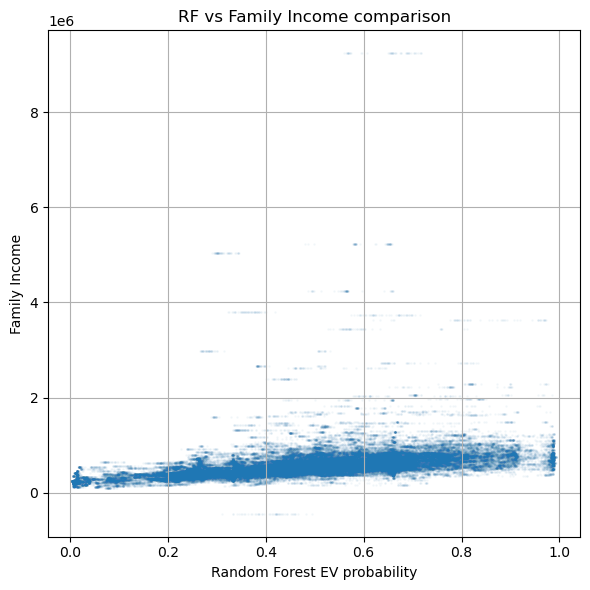

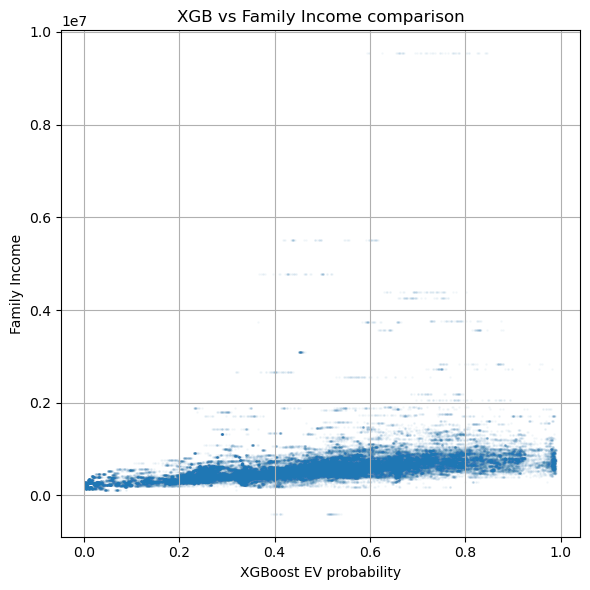

In [15]:
# Scatter plots
import matplotlib.pyplot as plt

# Convert only the needed columns to pandas/numpy for plotting
plot_df = df_corr.select([
    "rf_EV_probability",
    "Family_Income_rf",
    "xgb_EV_probability",
    "Family_Income_xgb"
]).to_pandas()

plt.figure(figsize=(6, 6))
plt.scatter(
    plot_df["rf_EV_probability"],
    plot_df["Family_Income_rf"],
    alpha=0.03,
    s=1
)

plt.xlabel("Random Forest EV probability")
plt.ylabel("Family Income")
plt.title("RF vs Family Income comparison")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 6))
plt.scatter(
    plot_df["xgb_EV_probability"],
    plot_df["Family_Income_xgb"],
    alpha=0.03,
    s=1
)

plt.xlabel("XGBoost EV probability")
plt.ylabel("Family Income")
plt.title("XGB vs Family Income comparison")
plt.grid(True)
plt.tight_layout()
plt.show()


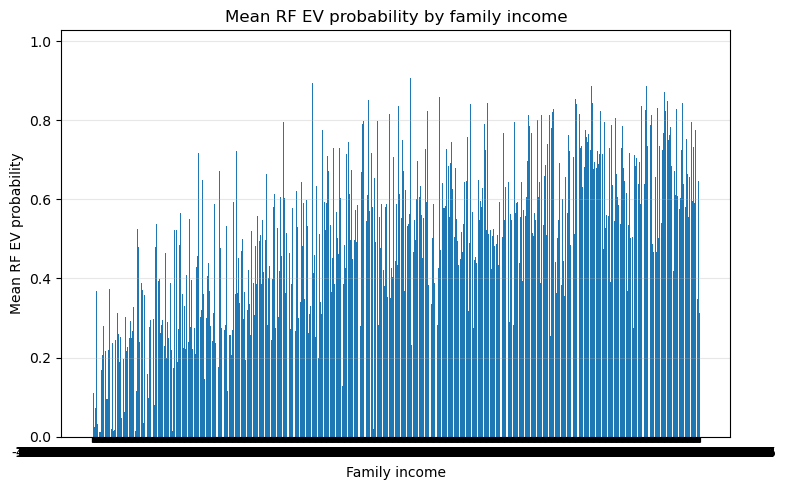

In [ ]:
# Bar Plots
# -----------------------------
# 1. RF: mean EV probability by income level
# -----------------------------
rf_income_summary = (
    df_corr
    .select(["Family_Income_rf", "rf_EV_probability"])
    .drop_nulls()
    .group_by("Family_Income_rf")
    .agg([
        pl.col("rf_EV_probability").mean().alias("mean_rf_EV_probability"),
        pl.col("rf_EV_probability").std().alias("std_rf_EV_probability"),
        pl.len().alias("n_obs"),
    ])
    .with_columns([
        (1.96 * pl.col("std_rf_EV_probability") / pl.col("n_obs").sqrt())
        .alias("ci95_rf")
    ])
    .sort("Family_Income_rf")
)

rf_pdf = rf_income_summary.to_pandas()

plt.figure(figsize=(8, 5))

plt.bar(
    rf_pdf["Family_Income_rf"].astype(str),
    rf_pdf["mean_rf_EV_probability"],
    # yerr=rf_pdf["ci95_rf"],
    # capsize=4
)

plt.xlabel("Family income [kDKK]")
plt.ylabel("Mean RF EV probability")
plt.title("Mean RF EV probability by family income")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()